#TP FUNDAMENTOS DEL DESARROLLO DE SOFTWARE Y ANALISIS DE DATOS CON PYTHON

El objetivo fue analizar la formación de precios en el mercado inmobiliario porteño, identificando:

Patrones de precio por barrio.

Relación entre precio, superficie y tipo de propiedad.

Diferencias entre zonas del norte, centro y sur de la ciudad.

### Cargo las principales librerias que voy a usar (o están a disposición) y cargo el dataset que voy a utilizar

In [ ]:
# las librerías escenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Cargar dataset desde Drive
df = pd.read_csv("/bsas_realstate_on_sale_properati_dataset_2020.csv")


Conocimiento de los datos

Exploro la estructura del dataset: cantidad de columnas y filas, tipos de datos.

In [ ]:
# Mostrar primeras filas
df.head()

,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,title,description,property_type,operation_type
0,2019-10-17,2019-12-23,2019-10-17,-34.605880,-58.384949,Argentina,Capital Federal,San Cristobal,7.0,7.0,2.0,140.0,140.0,153000.0,USD,"***Venta semipiso centro, ideal hostel*****",DESCRIPCION DE LA PROPIEDAD: Departamento de 1...,Departamento,Venta
1,2019-10-17,2019-11-21,2019-10-17,-34.624056,-58.412110,Argentina,Capital Federal,Boedo,2.0,1.0,2.0,70.0,58.0,159000.0,USD,Espectacular PH reciclado en Boedo sin expensas.,PH reciclado en Boedo a una cuadra de la plaz...,PH,Venta
2,2019-10-17,2019-11-01,2019-10-17,-34.593569,-58.427474,Argentina,Capital Federal,Palermo,2.0,1.0,1.0,45.0,45.0,125000.0,USD,Depto.tipo casa de 2 ambientes en Venta en Pal...,"2 ambienets amplio , excelente estado , patio ...",PH,Venta
3,2019-10-17,2019-12-23,2019-10-17,-34.581294,-58.436754,Argentina,Capital Federal,Palermo,2.0,1.0,1.0,85.0,50.0,295000.0,USD,COSTA RICA 5800 / PALERMO HOLLYWOOD / VENTA PH...,HERMOSO PH EN PALERMO!!!2 AMBIENTES TOTALMENTE...,PH,Venta
4,2019-10-17,2020-03-11,2019-10-17,-34.914194,-57.938219,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,2.0,1.0,1.0,50.0,35.0,40000.0,USD,58 entre 1 y 2 Venta de departamento en ph.1 ...,58 entre 1 y 2 Venta de departamento en PH. P...,PH,Venta


In [ ]:
df.shape

(146660, 19)

In [ ]:
df.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,136735.000000,136701.000000,146660.000000,146660.000000,140703.000000,126133.000000,125046.000000,1.466600e+05
mean,-34.604896,-58.465304,3.079817,1.983240,1.599994,216.872888,112.818011,2.412211e+05
std,0.468428,0.486190,1.416352,1.151304,0.889324,2037.606649,916.857584,3.185195e+05
min,-35.318457,-180.000000,1.000000,0.000000,1.000000,10.000000,1.000000,5.500000e+03
25%,-34.627667,-58.504012,2.000000,1.000000,1.000000,52.000000,47.000000,1.110000e+05
50%,-34.600943,-58.443262,3.000000,2.000000,1.000000,78.000000,68.000000,1.660000e+05
75%,-34.574600,-58.407586,4.000000,3.000000,2.000000,140.000000,108.000000,2.650000e+05
max,85.051129,-57.805832,35.000000,15.000000,14.000000,193549.000000,126062.000000,3.243423e+07


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146660 entries, 0 to 146659
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   start_date       146660 non-null  object 
 1   end_date         146660 non-null  object 
 2   created_on       146660 non-null  object 
 3   lat              136735 non-null  float64
 4   lon              136701 non-null  float64
 5   l1               146660 non-null  object 
 6   l2               146660 non-null  object 
 7   l3               146660 non-null  object 
 8   rooms            146660 non-null  float64
 9   bedrooms         146660 non-null  float64
 10  bathrooms        140703 non-null  float64
 11  surface_total    126133 non-null  float64
 12  surface_covered  125046 non-null  float64
 13  price            146660 non-null  float64
 14  currency         146660 non-null  object 
 15  title            146660 non-null  object 
 16  description      146660 non-null  obje

In [ ]:
df.columns

Index(['start_date', 'end_date', 'created_on', 'lat', 'lon', 'l1', 'l2', 'l3',
       'rooms', 'bedrooms', 'bathrooms', 'surface_total', 'surface_covered',
       'price', 'currency', 'title', 'description', 'property_type',
       'operation_type'],
      dtype='object')

In [ ]:
#Porcentaje de nulos por columna
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
print("Porcentaje de valores nulos por columna:")
print(porcentaje_nulos)


Porcentaje de valores nulos por columna:
start_date          0.000000
end_date            0.000000
created_on          0.000000
lat                 6.767353
lon                 6.790536
l1                  0.000000
l2                  0.000000
l3                  0.000000
rooms               0.000000
bedrooms            0.000000
bathrooms           4.061776
surface_total      13.996318
surface_covered    14.737488
price               0.000000
currency            0.000000
title               0.000000
description         0.000000
property_type       0.000000
operation_type      0.000000
dtype: float64


In [ ]:
# Reemplazar nulos por la mediana (forma recomendada)
df['surface_total'] = df['surface_total'].fillna(df['surface_total'].median())
df['surface_covered'] = df['surface_covered'].fillna(df['surface_covered'].median())

# Reemplazo los nulos



In [ ]:
 # Copia del dataset original
data = df.copy()

# Eliminar duplicados
data = data.drop_duplicates()

# Saco filas con precios o superficies nulas o 0
data = data[(data['price'] > 0) & (data['surface_total'] > 10)]

# Crear columna de precio por m²
data['price_m2'] = data['price'] / data['surface_total']

# Quitar outliers (por IQR)
Q1 = data['price_m2'].quantile(0.25)
Q3 = data['price_m2'].quantile(0.75)
IQR = Q3 - Q1
data = data[(data['price_m2'] >= Q1 - 1.5*IQR) & (data['price_m2'] <= Q3 + 1.5*IQR)]

data.head()


,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,title,description,property_type,operation_type,price_m2
0,2019-10-17,2019-12-23,2019-10-17,-34.605880,-58.384949,Argentina,Capital Federal,San Cristobal,7.0,7.0,2.0,140.0,140.0,153000.0,USD,"***Venta semipiso centro, ideal hostel*****",DESCRIPCION DE LA PROPIEDAD: Departamento de 1...,Departamento,Venta,1092.857143
1,2019-10-17,2019-11-21,2019-10-17,-34.624056,-58.412110,Argentina,Capital Federal,Boedo,2.0,1.0,2.0,70.0,58.0,159000.0,USD,Espectacular PH reciclado en Boedo sin expensas.,PH reciclado en Boedo a una cuadra de la plaz...,PH,Venta,2271.428571
2,2019-10-17,2019-11-01,2019-10-17,-34.593569,-58.427474,Argentina,Capital Federal,Palermo,2.0,1.0,1.0,45.0,45.0,125000.0,USD,Depto.tipo casa de 2 ambientes en Venta en Pal...,"2 ambienets amplio , excelente estado , patio ...",PH,Venta,2777.777778
3,2019-10-17,2019-12-23,2019-10-17,-34.581294,-58.436754,Argentina,Capital Federal,Palermo,2.0,1.0,1.0,85.0,50.0,295000.0,USD,COSTA RICA 5800 / PALERMO HOLLYWOOD / VENTA PH...,HERMOSO PH EN PALERMO!!!2 AMBIENTES TOTALMENTE...,PH,Venta,3470.588235
4,2019-10-17,2020-03-11,2019-10-17,-34.914194,-57.938219,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,2.0,1.0,1.0,50.0,35.0,40000.0,USD,58 entre 1 y 2 Venta de departamento en ph.1 ...,58 entre 1 y 2 Venta de departamento en PH. P...,PH,Venta,800.000000


In [ ]:
#Porcentaje de nulos por columna
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
print("Porcentaje de valores nulos por columna:")
print(porcentaje_nulos)

Porcentaje de valores nulos por columna:
start_date         0.000000
end_date           0.000000
created_on         0.000000
lat                6.767353
lon                6.790536
l1                 0.000000
l2                 0.000000
l3                 0.000000
rooms              0.000000
bedrooms           0.000000
bathrooms          4.061776
surface_total      0.000000
surface_covered    0.000000
price              0.000000
currency           0.000000
title              0.000000
description        0.000000
property_type      0.000000
operation_type     0.000000
dtype: float64


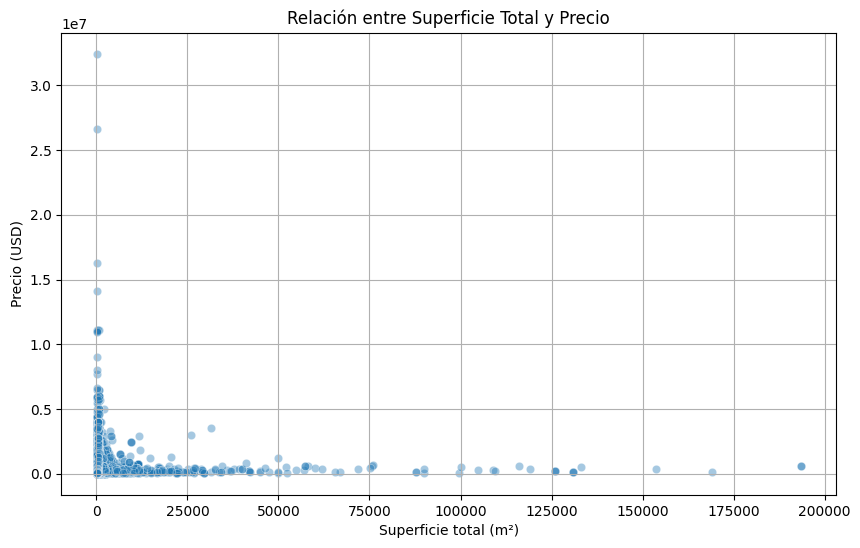

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(x='surface_total', y='price', data=df, alpha=0.4)

plt.title('Relación entre Superficie Total y Precio')
plt.xlabel('Superficie total (m²)')
plt.ylabel('Precio (USD)')
plt.grid(True)
plt.show()



In [ ]:
# Calcular IQR (rango intercuartílico)
Q1 = df['surface_total'].quantile(0.25)
Q3 = df['surface_total'].quantile(0.75)
IQR = Q3 - Q1

# Filtrar propiedades dentro de 1.5 veces el IQR
df = df[(df['surface_total'] >= (Q1 - 1.5 * IQR)) & (df['surface_total'] <= (Q3 + 1.5 * IQR))]

# Hacer lo mismo para el precio
Q1_p = df['price'].quantile(0.25)
Q3_p = df['price'].quantile(0.75)
IQR_p = Q3_p - Q1_p

df = df[(df['price'] >= (Q1_p - 1.5 * IQR_p)) & (df['price'] <= (Q3_p + 1.5 * IQR_p))]

print(f"Dataset filtrado: {df.shape[0]} filas restantes")


Dataset filtrado: 121390 filas restantes


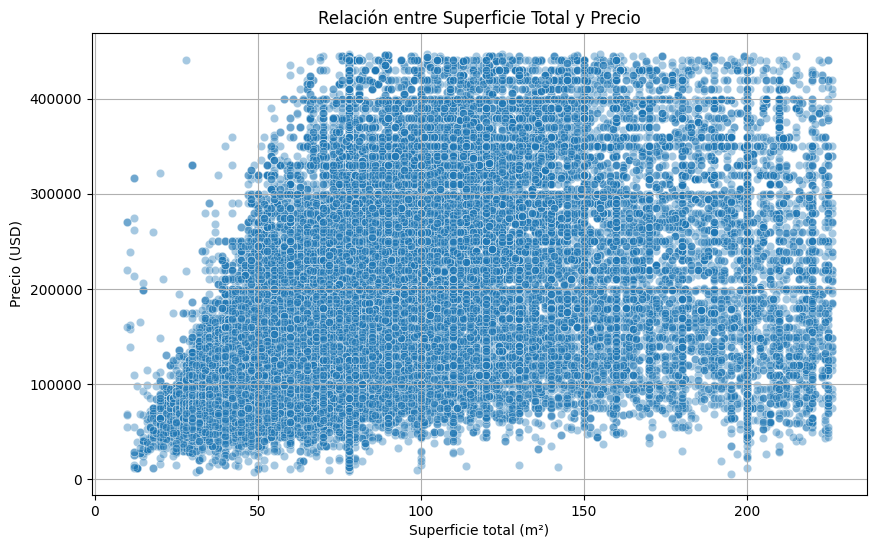

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(x='surface_total', y='price', data=df, alpha=0.4)

plt.title('Relación entre Superficie Total y Precio')
plt.xlabel('Superficie total (m²)')
plt.ylabel('Precio (USD)')
plt.grid(True)
plt.show()


El gráfico de dispersión entre la superficie total y el precio muestra una relación positiva bastante visible, donde las propiedades de mayor tamaño tienden a tener precios más altos. La concentración de puntos entre 30 y 150 m², con valores de hasta aproximadamente 300.000 USD, refleja el rango típico del mercado medio de CABA.
Si bien existe una tendencia ascendente, la amplitud de la dispersión indica que el precio no depende únicamente de la superficie, sino también de otros factores como el barrio, el tipo de propiedad o las características constructivas. Despues de eliminar los valores atípicos, la distribución se vuelve más homogénea y representativa, permitiendo identificar patrones de comportamiento más realistas del mercado inmobiliario.

/tmp/ipython-input-2648263160.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


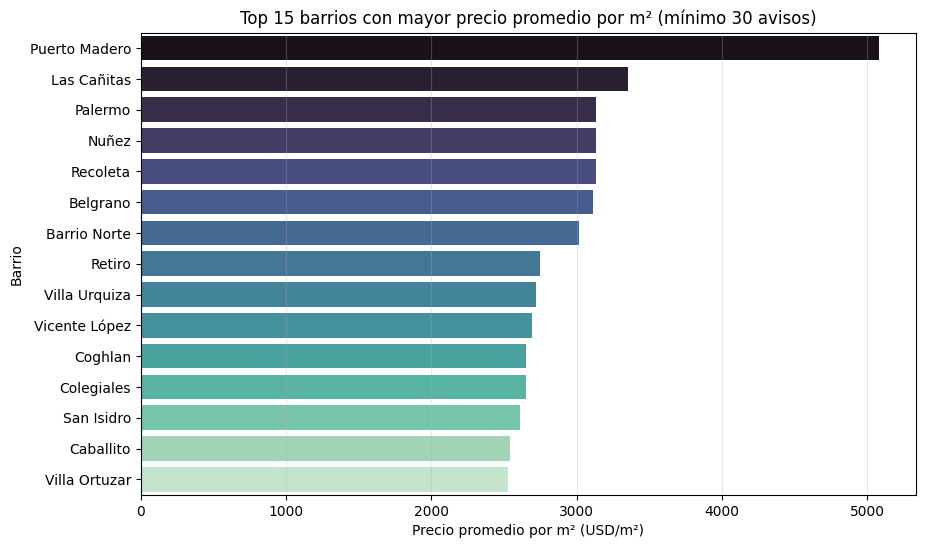

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

 #Calcular precio por m²
df['price_m2'] = df['price'] / df['surface_total']

# Agrupo por barrio
barrios = (
    df.groupby('l3')
      .agg(
          promedio_precio_m2=('price_m2', 'mean'),
          cantidad=('price_m2', 'count')
      )
      .reset_index()
)

# Filtrar barrios con al menos 30 avisos
barrios_filtrados = barrios[barrios['cantidad'] >= 30].copy()  # copy() evita el FutureWarning

# Asegurar que la columna sea numérica
barrios_filtrados['promedio_precio_m2'] = pd.to_numeric(barrios_filtrados['promedio_precio_m2'], errors='coerce')
barrios_filtrados['promedio_precio_m2'] = barrios_filtrados['promedio_precio_m2'].fillna(0)

# Tomar los 15 barrios más caros
top_barrios = barrios_filtrados.sort_values(by='promedio_precio_m2', ascending=False).head(15)

# Graficar
plt.figure(figsize=(10,6))
sns.barplot(
    data=top_barrios,
    x='promedio_precio_m2',
    y='l3',
    palette='mako'
)
plt.title('Top 15 barrios con mayor precio promedio por m² (mínimo 30 avisos)')
plt.xlabel('Precio promedio por m² (USD/m²)')
plt.ylabel('Barrio')
plt.grid(axis='x', alpha=0.3)
plt.show()


/tmp/ipython-input-3920919105.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


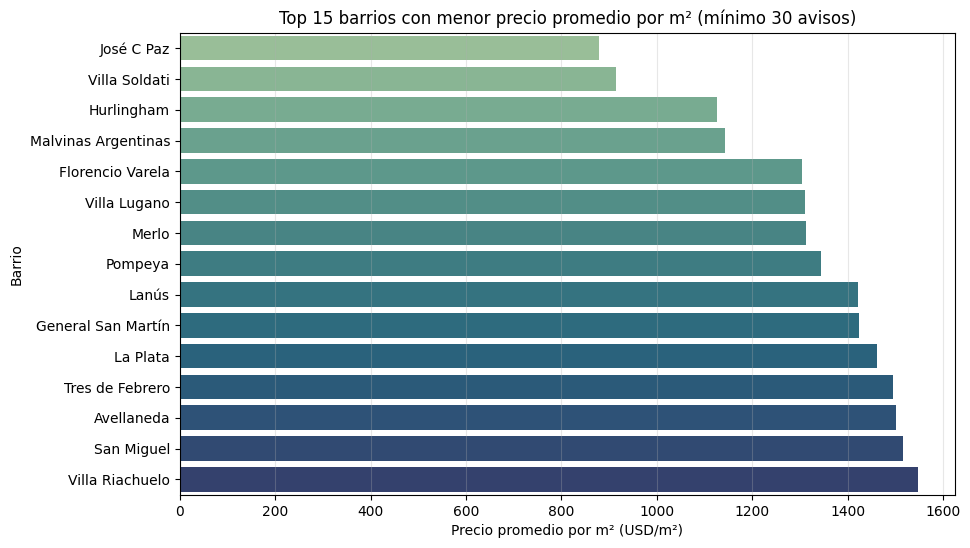

In [ ]:
# Ordenar por precio promedio (de menor a mayor) y tomar los 15 más baratos
bottom_barrios = barrios_filtrados.sort_values(by='promedio_precio_m2', ascending=True).head(15)

# Graficar
plt.figure(figsize=(10,6))
sns.barplot(
    data=bottom_barrios,
    x='promedio_precio_m2',
    y='l3',
    palette='crest'
)
plt.title('Top 15 barrios con menor precio promedio por m² (mínimo 30 avisos)')
plt.xlabel('Precio promedio por m² (USD/m²)')
plt.ylabel('Barrio')
plt.grid(axis='x', alpha=0.3)
plt.show()


In [ ]:
# Agrupar por barrio y calcular promedio de precio por m²
agg_barrio = (
    df.groupby('l3')
      .agg(
          price_m2_mean=('price_m2', 'mean'),
          count=('price_m2', 'count')
      )
      .query("count >= 20")  # filtramos barrios con al menos 20 avisos
      .sort_values('price_m2_mean', ascending=False)
)

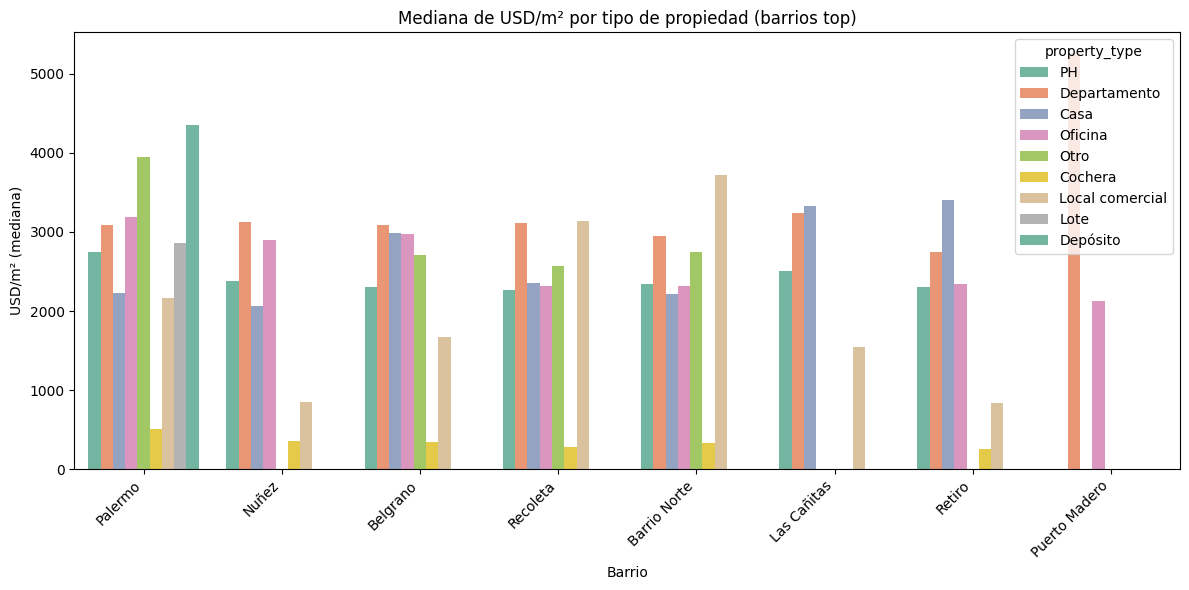

In [ ]:
place_col = 'l3'           # columna de barrios
ptype_col = 'property_type'  # columna del tipo de propiedad (Departamento, PH, etc.)

# Precio por m2 por tipo de propiedad en barrios populares
if ptype_col:
    barrios_pop = agg_barrio.head(8).index.get_level_values(0).tolist()
    df_pop = df[df[place_col].isin(barrios_pop)]
    plt.figure(figsize=(12,6))
    sns.barplot(
        data=df_pop,
        x=place_col,
        y="price_m2",
        hue=ptype_col,
        estimator="median",
        errorbar=None,
        palette="Set2"
    )
    plt.xticks(rotation=45, ha="right")
    plt.title("Mediana de USD/m² por tipo de propiedad (barrios top)")
    plt.ylabel("USD/m² (mediana)")
    plt.xlabel("Barrio")
    plt.legend(title=ptype_col)
    plt.tight_layout()
    plt.show()



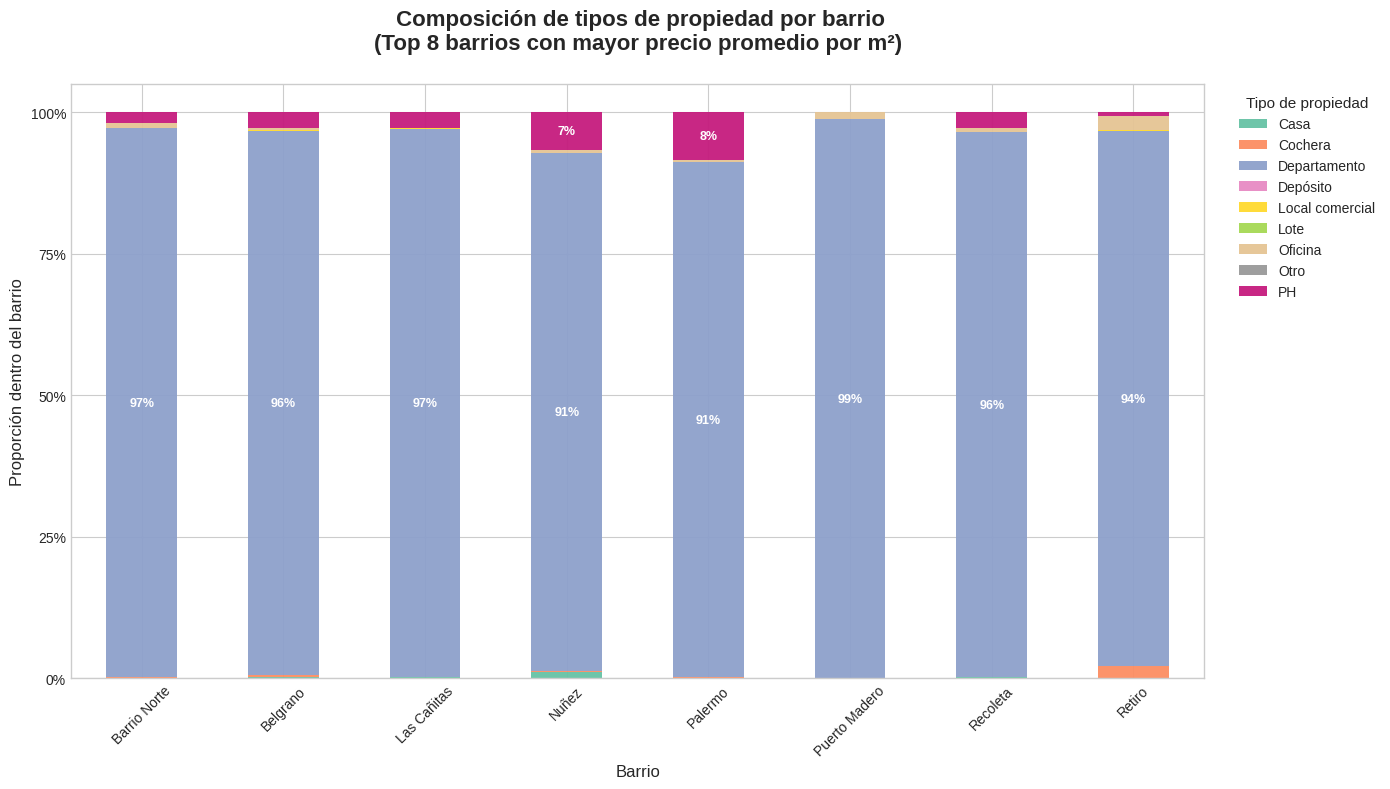

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#  Calcular el precio promedio por m² por barrio ---
price_avg = (
    df.groupby('l3')['price_m2']
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index
)

# Filtrar esos barrios ---
df_top = df[df['l3'].isin(price_avg)]

# Calcular proporción de tipos de propiedad ---
comp = (
    df_top.groupby(['l3', 'property_type'])
    .size()
    .reset_index(name='count')
)
comp['prop'] = comp.groupby('l3')['count'].transform(lambda x: x / x.sum())

# Pivotear para el gráfico apilado ---
pivot = comp.pivot(index='l3', columns='property_type', values='prop').fillna(0)
pivot = pivot[sorted(pivot.columns)]

# Paleta personalizada (colores mejor diferenciados) ---
custom_colors = {
    'Casa': '#66c2a5',
    'Casa de campo': '#1a9850',
    'Cochera': '#fc8d62',
    'Departamento': '#8da0cb',
    'Depósito': '#e78ac3',
    'Local comercial': '#ffd92f',
    'Lote': '#a6d854',
    'Oficina': '#e5c494',
    'Otro': '#999999',
    'PH': '#c51b7d'
}
colors = [custom_colors.get(col, '#cccccc') for col in pivot.columns]

# --Configuración general del gráfico ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 8))

pivot.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='none', alpha=0.95)

# Agregar etiquetas porcentuales ---
for i, barrio in enumerate(pivot.index):
    y_offset = 0
    for tipo in pivot.columns:
        prop = pivot.loc[barrio, tipo]
        if prop > 0.05:  # solo mostrar si es mayor al 5%
            ax.text(
                i,
                y_offset + prop / 2,
                f"{prop*100:.0f}%",
                ha='center',
                va='center',
                fontsize=9,
                color='white',
                fontweight='bold'
            )
        y_offset += prop

# Títulos y ejes ---
ax.set_title(
    ' Composición de tipos de propiedad por barrio\n(Top 8 barrios con mayor precio promedio por m²)',
    fontsize=16,
    pad=25,
    weight='bold'
)
ax.set_xlabel('Barrio', fontsize=12)
ax.set_ylabel('Proporción dentro del barrio', fontsize=12)
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=45)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=10)

# Leyenda ---
ax.legend(
    title='Tipo de propiedad',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.show()


De los barrios más caros, nos fijamos cual es la composición, para entender un poco las variables que pueden importar en el precio final del m2. La mayoría muestran departamentos en su mayoria.

/tmp/ipython-input-3911477368.py:31: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


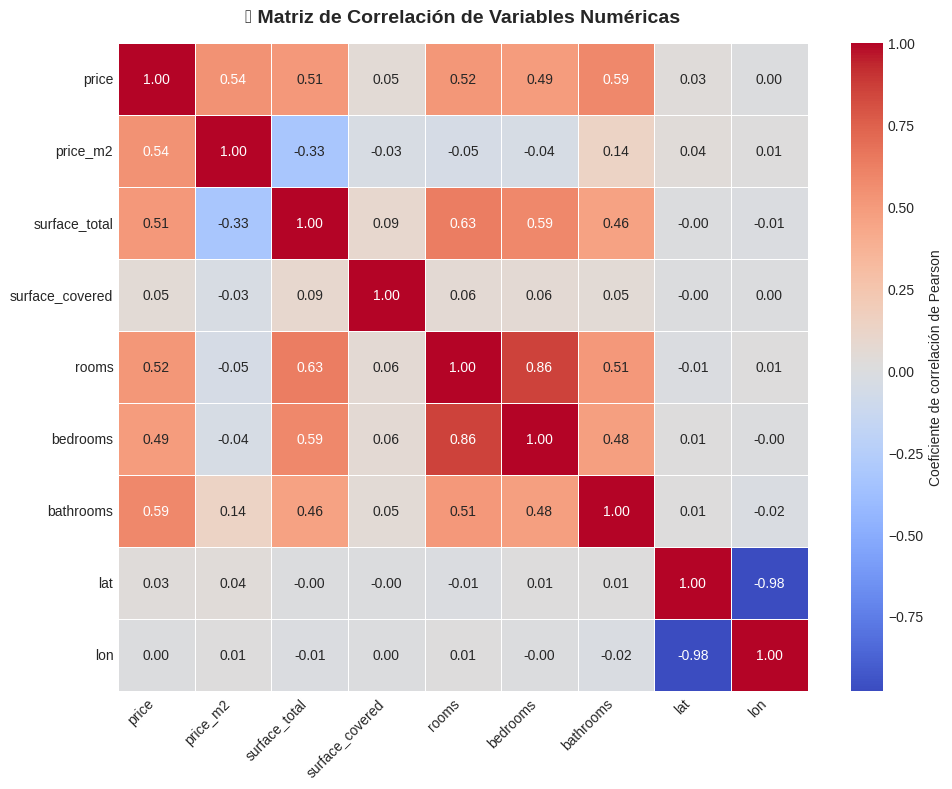

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Seleccionamos solo las columnas numéricas del DataFrame limpio
df_numerico = df.select_dtypes(include=np.number)

# 2️⃣ Calculamos la matriz de correlación
matriz_correlacion = df_numerico.corr().round(2)

# 3️⃣ Reordenamos las columnas para agrupar variables relacionadas
orden = [
    'price', 'price_m2', 'surface_total', 'surface_covered',
    'rooms', 'bedrooms', 'bathrooms', 'lat', 'lon'
]
matriz_correlacion = matriz_correlacion.reindex(index=orden, columns=orden)

# 4️⃣ Creamos el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlacion,
    annot=True,           # Muestra valores numéricos
    cmap='coolwarm',      # Rojo = correlación positiva, Azul = negativa
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de correlación de Pearson'}
)
plt.title('🔍 Matriz de Correlación de Variables Numéricas', fontsize=14, pad=15, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
